In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Combine Data CZ and GR.csv to Combine Data CZ and GR.csv


In [12]:
df = pd.read_csv("Combine Data CZ and GR.csv")

In [13]:
#First inspection
df.shape
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70224 entries, 0 to 70223
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ts_local                 70096 non-null  object 
 1   country                  70224 non-null  object 
 2   price_day_ahead_eur_mwh  70224 non-null  float64
 3   price_intraday_eur_mwh   0 non-null      float64
 4   load_actual_mw           70222 non-null  float64
 5   load_dayahead_mw         70193 non-null  float64
dtypes: float64(4), object(2)
memory usage: 3.2+ MB


In [27]:
#Filter for Greece
gr = df[df["country"] == "GR"].copy()


In [28]:
#cleaning columns
gr = gr.drop(columns=["price_intraday_eur_mwh"])

In [29]:
#Datetime conversion
gr["ts_local"] = pd.to_datetime(gr["ts_local"])
gr = gr.sort_values("ts_local")

In [30]:
#Set index (time series structure)
gr = gr.set_index("ts_local")

In [31]:
#Handle missing values
gr.isna().sum()
gr["load_actual_mw"] = gr["load_actual_mw"].interpolate()
gr["load_dayahead_mw"] = gr["load_dayahead_mw"].interpolate()

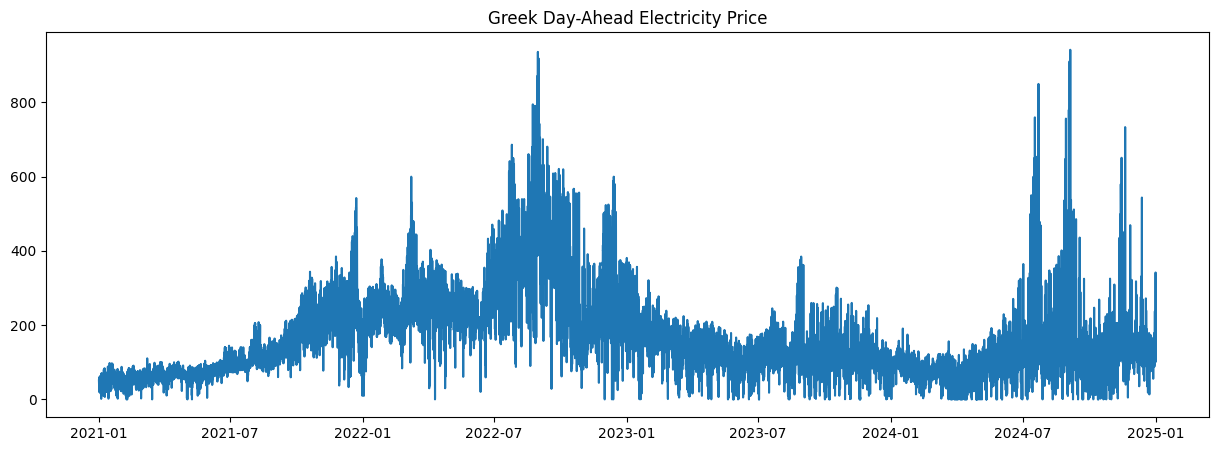

In [32]:
#First sanity check plot
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(gr["price_day_ahead_eur_mwh"])
plt.title("Greek Day-Ahead Electricity Price")
plt.show()

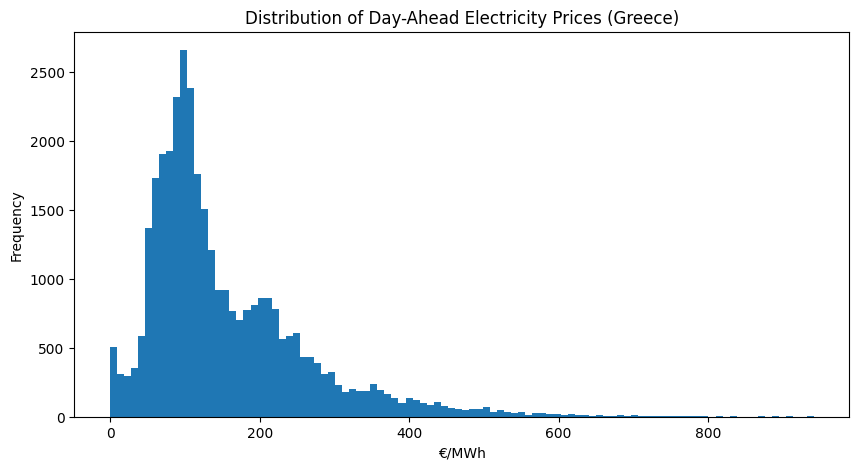

In [33]:
#Market Overview
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(gr["price_day_ahead_eur_mwh"], bins=100)
plt.title("Distribution of Day-Ahead Electricity Prices (Greece)")
plt.xlabel("€/MWh")
plt.ylabel("Frequency")
plt.show()

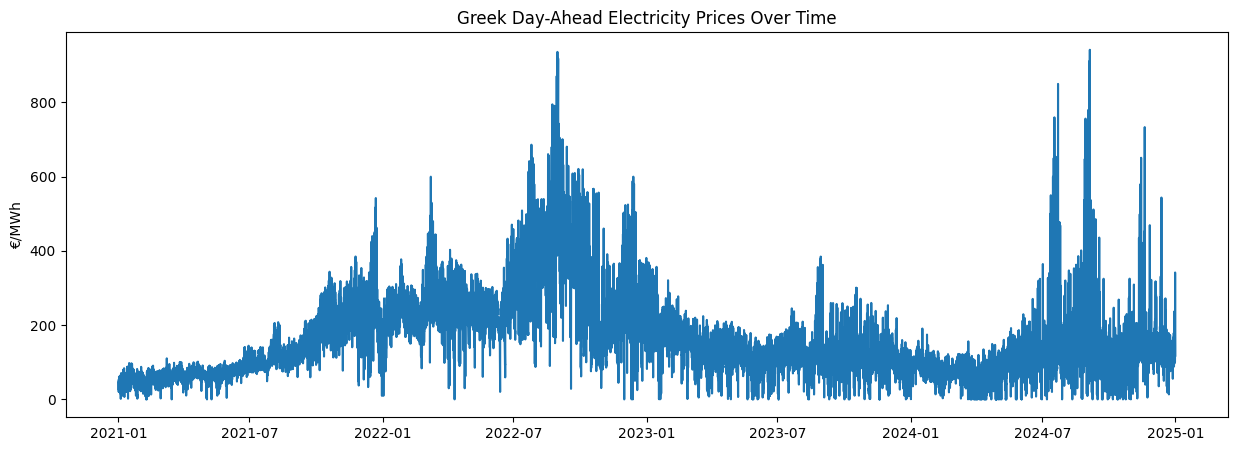

In [34]:
#Time series view
plt.figure(figsize=(15,5))
plt.plot(gr["price_day_ahead_eur_mwh"])
plt.title("Greek Day-Ahead Electricity Prices Over Time")
plt.ylabel("€/MWh")
plt.show()

In [35]:
#FEATURE ENGINEERING LAYER
#we will create features which copy electiricty markets
#Time features (seasonality of market)
gr["hour"] = gr.index.hour
gr["day_of_week"] = gr.index.dayofweek
gr["month"] = gr.index.month
gr["is_weekend"] = (gr["day_of_week"] >= 5).astype(int)

 Electricity has strong daily/weekly seasonality

In [36]:
#Lag features (core forecasting signal)
gr["price_lag_1"] = gr["price_day_ahead_eur_mwh"].shift(1)
gr["price_lag_24"] = gr["price_day_ahead_eur_mwh"].shift(24)
gr["price_lag_48"] = gr["price_day_ahead_eur_mwh"].shift(48)
gr["price_lag_168"] = gr["price_day_ahead_eur_mwh"].shift(168)

In [37]:
#Rolling statistics (market regime)
gr["rolling_mean_24"] = gr["price_day_ahead_eur_mwh"].rolling(24).mean()
gr["rolling_std_24"] = gr["price_day_ahead_eur_mwh"].rolling(24).std()

gr["rolling_mean_168"] = gr["price_day_ahead_eur_mwh"].rolling(168).mean()

In [38]:
#Load-based features (demand signal)
gr["load_gap"] = gr["load_actual_mw"] - gr["load_dayahead_mw"]
gr["load_ratio"] = gr["load_actual_mw"] / gr["load_dayahead_mw"]

forecast error → price pressure

In [39]:
#Clean dataset
gr_ml = gr.dropna().copy()

In [40]:
#Final ML dataset
features = [
    "hour", "day_of_week", "month", "is_weekend",
    "price_lag_1", "price_lag_24", "price_lag_48", "price_lag_168",
    "rolling_mean_24", "rolling_std_24", "rolling_mean_168",
    "load_actual_mw", "load_dayahead_mw",
    "load_gap", "load_ratio"
]

target = "price_day_ahead_eur_mwh"

X = gr_ml[features]
y = gr_ml[target]

In [41]:
#Train/Test split
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [42]:
#Baseline Model (Linear Regression)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [43]:
#Predictions & Metrics
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)

Baseline Linear Regression Results
MAE: 17.447606410663575
RMSE: 34.58363487953387


linear regression:

achieves "mean behavor" of the market but it does not achieves spikes / volatility
RMSE > MAE means outliers (price spikes)
energy market has fat tails (typical feature)

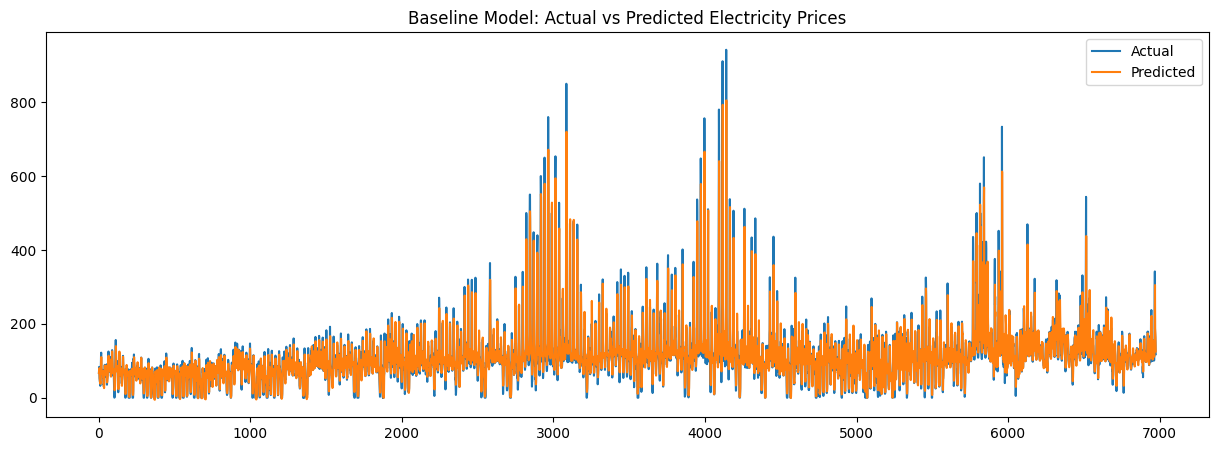

In [44]:
#Plot real vs predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Baseline Model: Actual vs Predicted Electricity Prices")
plt.show()

In [45]:
#XGBoost model (realistic setup)
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [46]:
#train model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [47]:
#predictions
y_pred_xgb = xgb.predict(X_test)

In [48]:
#evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)

XGBoost Results
MAE: 14.79093595554608
RMSE: 30.3148478151661


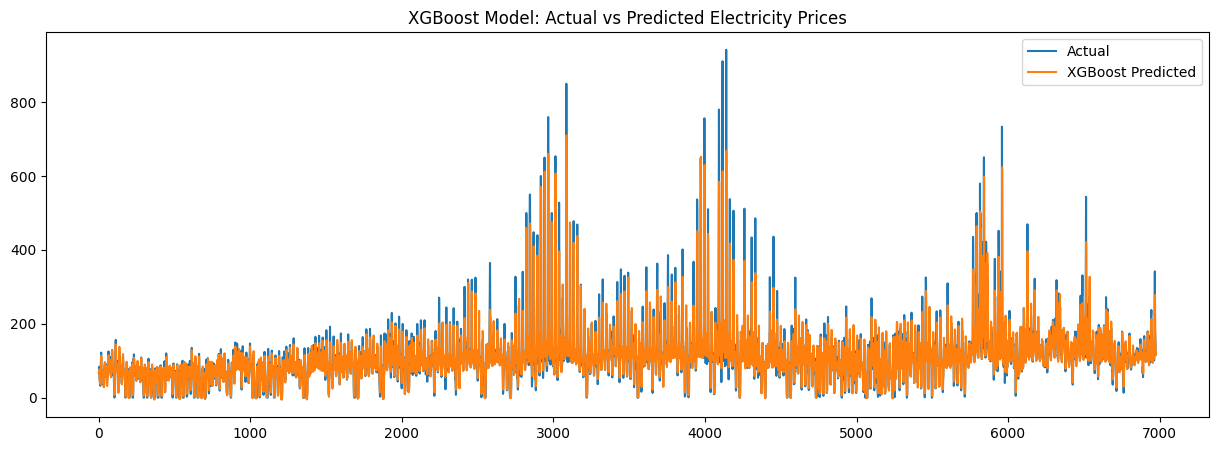

In [49]:
#Actual vs Predicted Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_xgb, label="XGBoost Predicted")
plt.legend()
plt.title("XGBoost Model: Actual vs Predicted Electricity Prices")
plt.show()

In [50]:
#FEATURE IMPORTANCE
import pandas as pd

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
})

importance = importance.sort_values(by="importance", ascending=False)

importance

,feature,importance
4,price_lag_1,0.705965
5,price_lag_24,0.123088
8,rolling_mean_24,0.088820
7,price_lag_168,0.018308
0,hour,0.008345
3,is_weekend,0.007646
1,day_of_week,0.006994
10,rolling_mean_168,0.006482
6,price_lag_48,0.006227
12,load_dayahead_mw,0.005274


price_lag_1 → 70.6%
it shows:The market is highly autoregressive at short horizon.
yesterday → almost defines today
microstructure dominates fundamentals

price_lag_24 → 12.3%
same hour previous day has strong influence

rolling_mean_24 → 8.8%
 Market regime / smoothing effect: “price level context”

 price_lag_168 → 1.8% Weekly effect exists but it's  weak
 hour → σχεδόν μηδενικό
 insight:Time-of-day alone is not enough without market memory variables

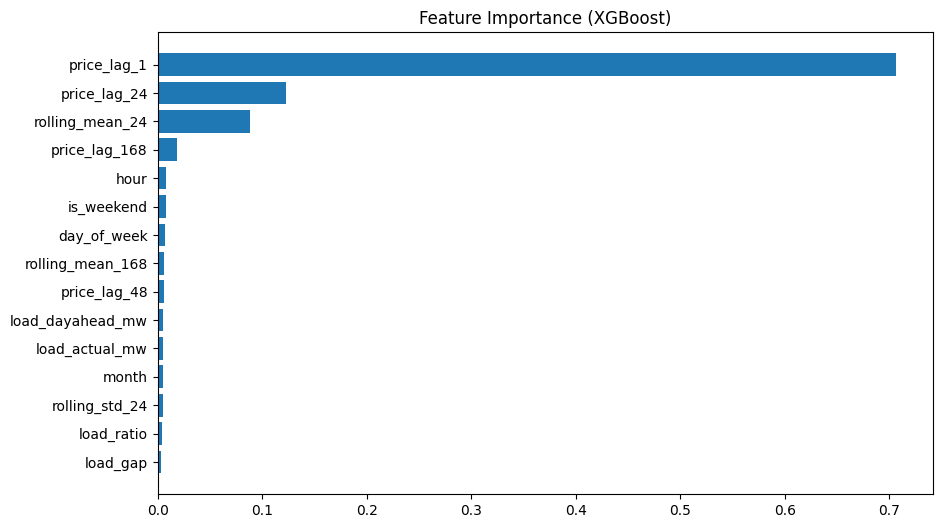

In [51]:
plt.figure(figsize=(10,6))
plt.barh(importance["feature"], importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.show()

the model is primarily driven by lagged price effects and demand indicators, which confirms strong autocorrelation and load-driven pricing dynamics in the Greek electricity market

| Model             | MAE       | RMSE      |
| ----------------- | --------- | --------- |
| Linear Regression | 17.45     | 34.58     |
| XGBoost           | **14.79** | **30.31** |
electricity prices are non-linear and memory-driven

HAP = “Which market factors pushed electricity price up or down?”

In [52]:
!pip install shap
import shap

In [53]:
#Create SHAP explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

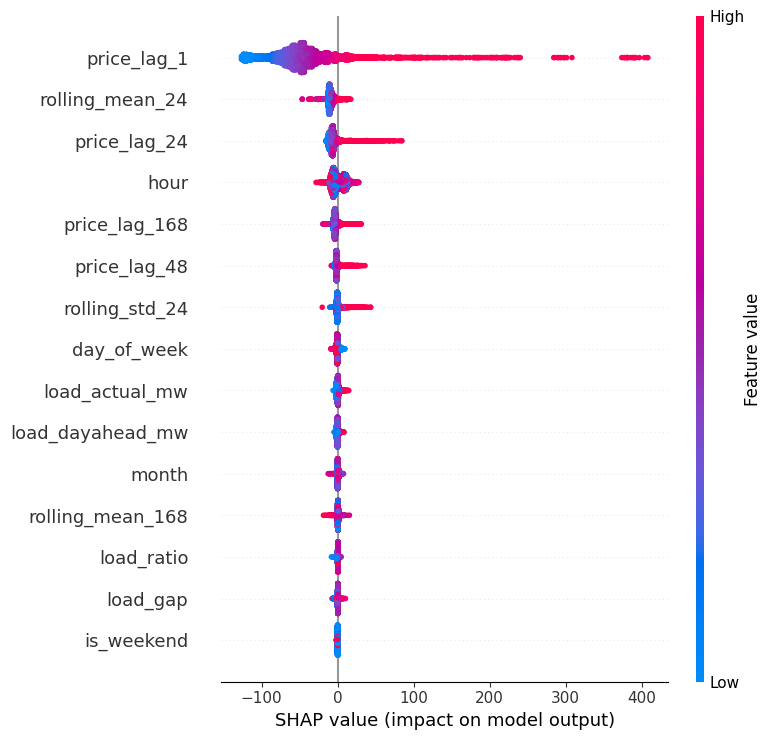

In [54]:
#Global feature importance (SHAP)
shap.summary_plot(shap_values, X_test)

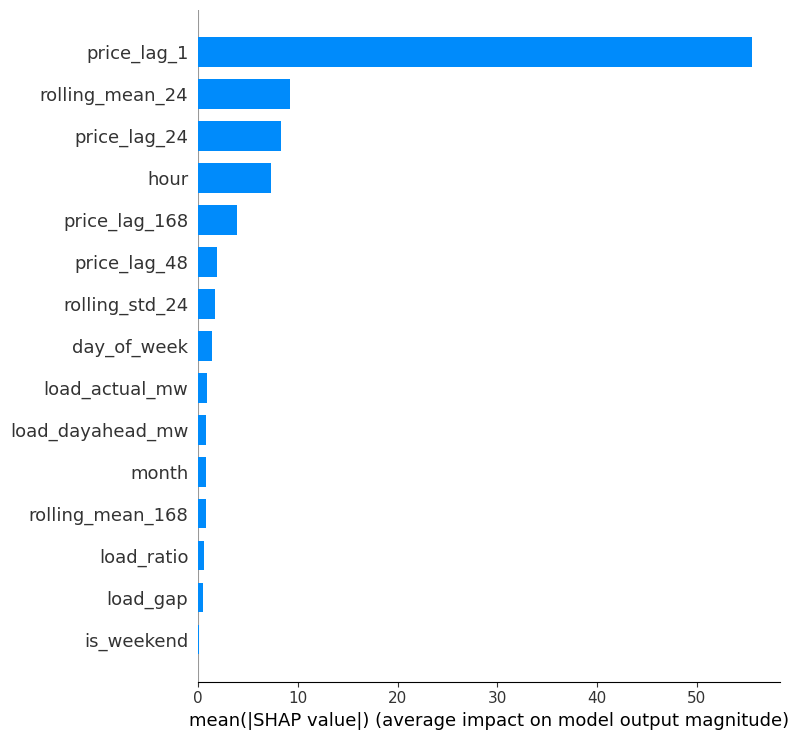

In [55]:
#Bar plot (global ranking)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [56]:
#Local explanation
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [57]:
from google.colab import files
uploaded = files.upload()

Saving PNGASEUUSDM.csv to PNGASEUUSDM.csv


In [58]:
df = pd.read_csv("PNGASEUUSDM.csv")
df.head()

,observation_date,PNGASEUUSDM
0,1992-01-01,2.38
1,1992-02-01,2.38
2,1992-03-01,2.38
3,1992-04-01,2.34
4,1992-05-01,2.34


In [59]:
df = df.rename(columns={
    "TTF": "ttf_price"
})

In [60]:
gas = df.copy()  # το gas dataset σου

gas['observation_date'] = pd.to_datetime(gas['observation_date'])
gas = gas.set_index('observation_date')
gas = gas.resample("D").mean()

In [61]:
electricity = gr["price_day_ahead_eur_mwh"].resample("D").mean()

In [63]:
#Merge datasets
data = pd.DataFrame({
    "electricity": electricity,
    "gas": gas["PNGASEUUSDM"]
}).dropna()

In [64]:
#Correlation analysis
data.corr()

,electricity,gas
electricity,1.000000,0.892102
gas,0.892102,1.000000


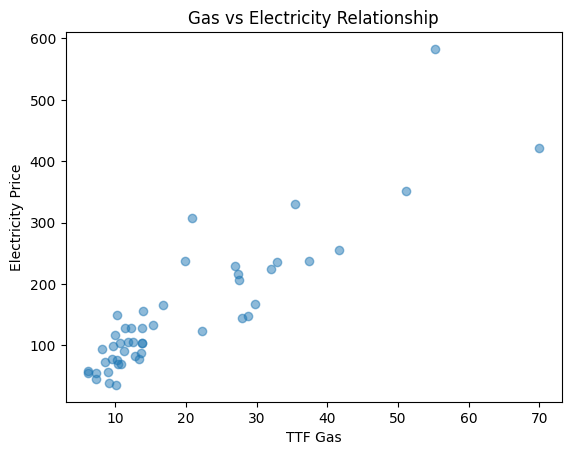

In [65]:
#Visual correlation intuition
import matplotlib.pyplot as plt

plt.scatter(data["gas"], data["electricity"], alpha=0.5)
plt.xlabel("TTF Gas")
plt.ylabel("Electricity Price")
plt.title("Gas vs Electricity Relationship")
plt.show()

In [66]:
#Stationarity check
data_ret = data.pct_change().dropna()

In [67]:
#VAR model setup
from statsmodels.tsa.api import VAR

In [68]:
#Fit model
model = VAR(data_ret)
results = model.fit(maxlags=5)
print(results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 04, Jul, 2026
Time:                     15:23:34
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -3.24828
Nobs:                     42.0000    HQIC:                  -3.82486
Log likelihood:          -9.86266    FPE:                  0.0160268
AIC:                     -4.15848    Det(Omega_mle):       0.0100645
--------------------------------------------------------------------
Results for equation electricity
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.157743         0.074527            2.117           0.034
L1.electricity        -0.381426         0.180060           -2.118           0.034
L1.gas                 0.834992         0.262131  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [69]:
#Granger-style interpretation
#Forecast
lag_order = results.k_ar

forecast_input = data_ret.values[-lag_order:]

forecast = results.forecast(y=forecast_input, steps=5)
print(forecast)

[[ 0.31070709  0.06588154]
 [ 0.13663515  0.05811956]
 [-0.00435493  0.04515761]
 [ 0.02447334  0.02857903]
 [ 0.07406767  0.03175713]]


Does gas help predict electricity prices?
Or is it just correlation?

In [70]:
from statsmodels.tsa.stattools import grangercausalitytests

In [71]:
#Prepare dataset
data_ret.head()

,electricity,gas
2021-02-01,0.282559,-0.154937
2021-03-01,-0.050861,0.005486
2021-04-01,-0.023685,0.173649
2021-05-01,0.045842,0.236447
2021-06-01,0.238209,0.146527


In [72]:
granger_data = data_ret[["electricity", "gas"]].dropna()

In [74]:
#Gas → Electricity causality test
grangercausalitytests(granger_data, maxlag=10, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=8.5074  , p=0.0056  , df_denom=43, df_num=1
ssr based chi2 test:   chi2=9.1010  , p=0.0026  , df=1
likelihood ratio test: chi2=8.3042  , p=0.0040  , df=1
parameter F test:         F=8.5074  , p=0.0056  , df_denom=43, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.2180  , p=0.0218  , df_denom=40, df_num=2
ssr based chi2 test:   chi2=9.4904  , p=0.0087  , df=2
likelihood ratio test: chi2=8.6113  , p=0.0135  , df=2
parameter F test:         F=4.2180  , p=0.0218  , df_denom=40, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.9684  , p=0.0151  , df_denom=37, df_num=3
ssr based chi2 test:   chi2=14.1577 , p=0.0027  , df=3
likelihood ratio test: chi2=12.2746 , p=0.0065  , df=3
parameter F test:         F=3.9684  , p=0.0151  , df_denom=37, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.0117  , p=0.0314  , df_d

{np.int64(1): ({'ssr_ftest': (np.float64(8.5074408628082),
    np.float64(0.005601438083702793),
    np.float64(43.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(9.100983248585518),
    np.float64(0.002554721240547212),
    np.int64(1)),
   'lrtest': (np.float64(8.304203558373715),
    np.float64(0.003955342378528476),
    np.int64(1)),
   'params_ftest': (np.float64(8.507440862808194),
    np.float64(0.005601438083702811),
    np.float64(43.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(4.217957765929067),
    np.float64(0.02176955560156929),
    np.float64(40.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(9.4904049733404),
    np.float64(0.008693301549883162),
    np.int64(2)),
   'lrtest': (np.float64(8.611296338891023),
    np.float64(0.013492137515714597),
    np.int64(2)),
   'params_ftest': (np.float64(4.2179577659290635),
    np.float64(0.02176955560156935),
    np.float64(40.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
       

In [75]:
#Reverse test
granger_reverse = data_ret[["gas", "electricity"]].dropna()

grangercausalitytests(granger_reverse, maxlag=10, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0938  , p=0.7608  , df_denom=43, df_num=1
ssr based chi2 test:   chi2=0.1004  , p=0.7514  , df=1
likelihood ratio test: chi2=0.1003  , p=0.7515  , df=1
parameter F test:         F=0.0938  , p=0.7608  , df_denom=43, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0696  , p=0.9328  , df_denom=40, df_num=2
ssr based chi2 test:   chi2=0.1567  , p=0.9246  , df=2
likelihood ratio test: chi2=0.1564  , p=0.9248  , df=2
parameter F test:         F=0.0696  , p=0.9328  , df_denom=40, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0561  , p=0.9823  , df_denom=37, df_num=3
ssr based chi2 test:   chi2=0.2000  , p=0.9776  , df=3
likelihood ratio test: chi2=0.1996  , p=0.9777  , df=3
parameter F test:         F=0.0561  , p=0.9823  , df_denom=37, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.1865  , p=0.9438  , df_d

{np.int64(1): ({'ssr_ftest': (np.float64(0.09383709007632401),
    np.float64(0.7608329807480662),
    np.float64(43.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.10038386380257919),
    np.float64(0.7513694679016194),
    np.int64(1)),
   'lrtest': (np.float64(0.10027449115287368),
    np.float64(0.7515004822878815),
    np.int64(1)),
   'params_ftest': (np.float64(0.09383709007632855),
    np.float64(0.7608329807480662),
    np.float64(43.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.0696365838133085),
    np.float64(0.9328455499655515),
    np.float64(40.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.1566823135799441),
    np.float64(0.9246489224701798),
    np.int64(2)),
   'lrtest': (np.float64(0.1564101745648543),
    np.float64(0.9247747475539968),
    np.int64(2)),
   'params_ftest': (np.float64(0.06963658381330709),
    np.float64(0.9328455499655557),
    np.float64(40.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
     

####IFR Model: What happens in electricity price if gas face a shock?

In [77]:
from statsmodels.tsa.api import VAR
model = VAR(data_ret)
results = model.fit(maxlags=5)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [78]:
#Impulse Response Function
irf = results.irf(10)

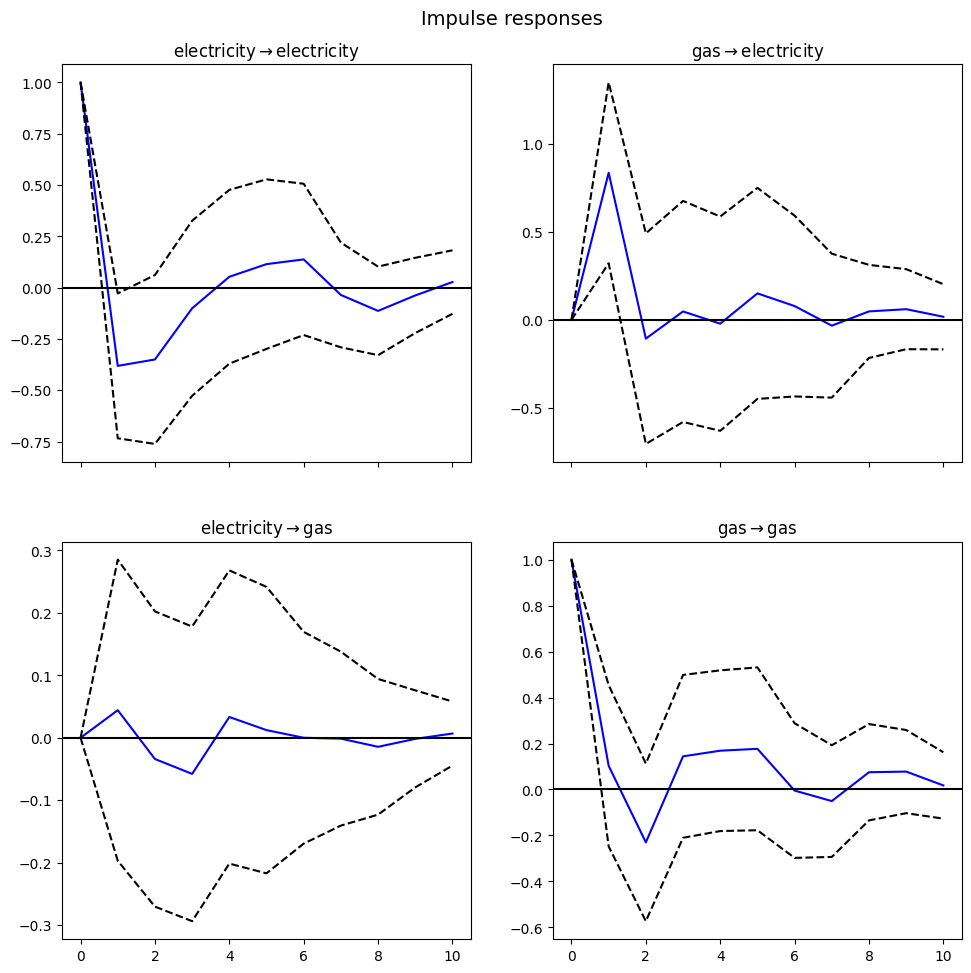

In [79]:
#Plot IRF (Gas → Electricity)
import matplotlib.pyplot as plt

irf.plot(orth=False)
plt.show()

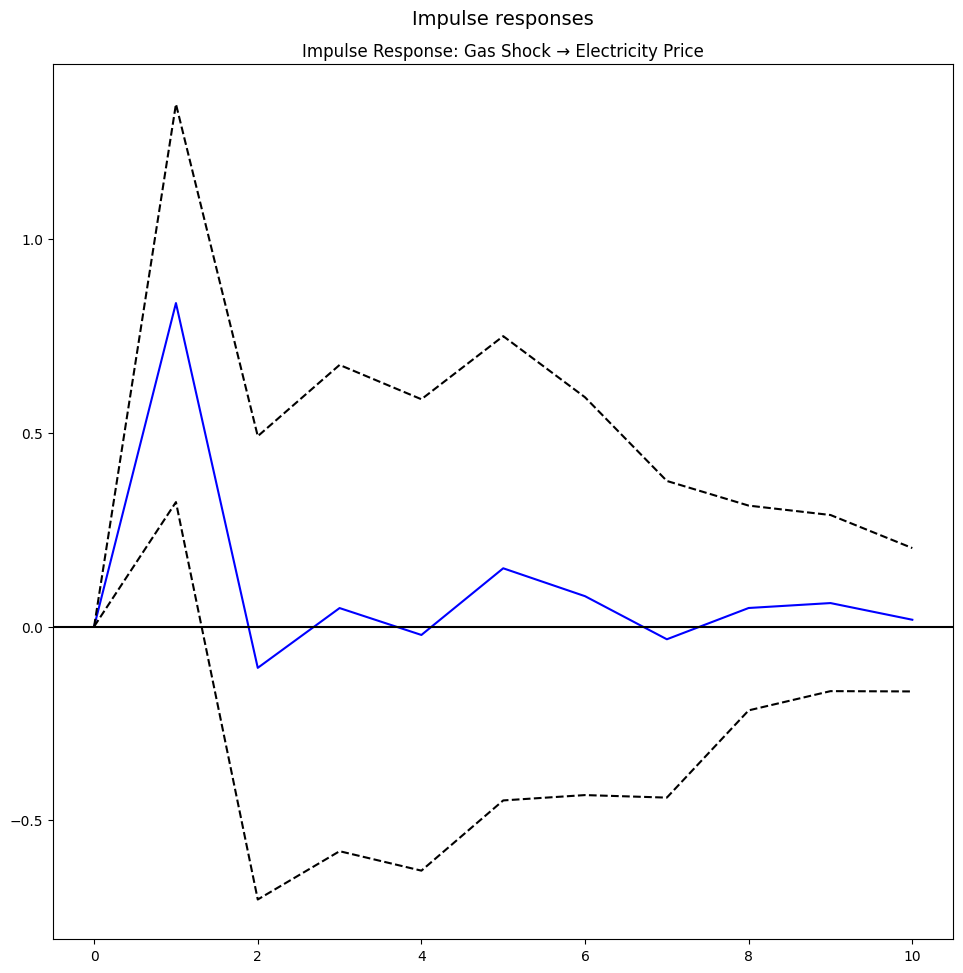

In [80]:
#Focused plot
irf.plot(impulse="gas", response="electricity")
plt.title("Impulse Response: Gas Shock → Electricity Price")
plt.show()